# Son 30 Günün Depremleri — İnteraktif Harita

USGS'in (ABD Jeoloji Araştırmaları Kurumu) ücretsiz, üyelik gerektirmeyen deprem servisinden
son 30 günde dünyada olan **2.5 ve üzeri** depremleri çekip tıklanabilir bir haritaya basıyoruz.

**Çıktılar** (`cikti/` klasörü):
- `deprem_haritasi.html` — tarayıcıda açılan interaktif harita
- `gunluk_deprem_sayisi.png` — günlük deprem sayısı grafiği

## 1. Kütüphaneler

- `requests`: internetten veri çekmek için
- `pandas`: veriyi tablo halinde işlemek için
- `folium`: Leaflet tabanlı interaktif harita çizmek için
- `matplotlib`: statik grafik çizmek için

In [1]:
from html import escape
from pathlib import Path

import folium
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests
from folium.plugins import Fullscreen, HeatMap

CIKTI = Path("cikti")
CIKTI.mkdir(exist_ok=True)

## 2. Veriyi çekme

USGS her birkaç dakikada güncellenen hazır GeoJSON dosyaları yayınlıyor.
`2.5_month.geojson` = son 30 gün, büyüklüğü 2.5 ve üzeri depremler.
GeoJSON, harita verisi için standart bir JSON formatı: her deprem bir `feature`,
koordinatlar `geometry` içinde, diğer bilgiler `properties` içinde.

In [2]:
URL = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/2.5_month.geojson"

yanit = requests.get(URL, timeout=30)
yanit.raise_for_status()  # hata varsa (404, 500 vb.) burada durur
veri = yanit.json()

print("Gelen deprem sayısı:", len(veri["features"]))
veri["features"][0]  # ilk kaydın ham hali

Gelen deprem sayısı: 1970


{'type': 'Feature',
 'properties': {'mag': 4.8,
  'place': 'South Sandwich Islands region',
  'time': 1790663929006,
  'updated': 1790665102040,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us6000tyat',
  'detail': 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/us6000tyat.geojson',
  'felt': None,
  'cdi': None,
  'mmi': None,
  'alert': None,
  'status': 'reviewed',
  'tsunami': 0,
  'sig': 354,
  'net': 'us',
  'code': '6000tyat',
  'ids': ',us6000tyat,',
  'sources': ',us,',
  'types': ',origin,phase-data,',
  'nst': 53,
  'dmin': 4.748,
  'rms': 0.88,
  'gap': 66,
  'magType': 'mb',
  'type': 'earthquake',
  'title': 'M 4.8 - South Sandwich Islands region'},
 'geometry': {'type': 'Point', 'coordinates': [-28.4628, -55.2555, 35]},
 'id': 'us6000tyat'}

## 3. Tabloya çevirme

Her `feature`'dan ihtiyacımız olan alanları alıp bir satır yapıyoruz.
USGS koordinatları `[boylam, enlem, derinlik]` sırasıyla veriyor — enlem/boylam sırası
karıştırmaya çok müsait, dikkat.
Zaman, 1970'ten beri geçen milisaniye olarak geliyor; bunu Türkiye saatine çeviriyoruz.

In [3]:
satirlar = []
for f in veri["features"]:
    boylam, enlem, derinlik = f["geometry"]["coordinates"]
    p = f["properties"]
    satirlar.append({
        "zaman": p["time"],
        "enlem": enlem,
        "boylam": boylam,
        "derinlik_km": derinlik,
        "buyukluk": p["mag"],
        "yer": p["place"] or "Bilinmiyor",
        "url": p["url"],
    })

df = pd.DataFrame(satirlar)
df["zaman"] = (
    pd.to_datetime(df["zaman"], unit="ms", utc=True)
    .dt.tz_convert("Europe/Istanbul")
)
df = df.dropna(subset=["buyukluk"]).sort_values("buyukluk").reset_index(drop=True)

print(df.shape)
df.tail()

(1970, 7)


,zaman,enlem,boylam,derinlik_km,buyukluk,yer,url
1965,2026-09-03 14:17:21.717000+03:00,52.1883,-169.3496,21.000,6.3,"89 km SSW of Nikolski, Alaska",https://earthquake.usgs.gov/earthquakes/eventp...
1966,2026-09-20 12:17:35.624000+03:00,-5.9021,146.0922,104.329,6.4,"49 km NNE of Kainantu, Papua New Guinea",https://earthquake.usgs.gov/earthquakes/eventp...
1967,2026-09-12 00:23:55.907000+03:00,-4.9832,106.8742,372.000,6.5,"126 km NNE of Teluknaga, Indonesia",https://earthquake.usgs.gov/earthquakes/eventp...
1968,2026-09-17 17:19:52.472000+03:00,52.9564,-171.5033,98.000,6.5,"177 km W of Nikolski, Alaska",https://earthquake.usgs.gov/earthquakes/eventp...
1969,2026-09-26 00:23:03.309000+03:00,-21.2982,168.6100,10.000,6.6,"80 km ENE of Tadine, New Caledonia",https://earthquake.usgs.gov/earthquakes/eventp...


Hızlı bir kontrol: büyüklük ve derinlik aralıkları mantıklı mı?

In [4]:
df[["buyukluk", "derinlik_km"]].describe().round(2)

,buyukluk,derinlik_km
count,1970.00,1970.00
mean,3.64,51.24
std,0.92,93.37
min,2.45,-3.43
25%,2.76,10.00
50%,3.41,14.40
75%,4.50,53.30
max,6.60,664.57


## 4. Büyüklüğe göre sınıflar, renk ve boyut

Depremleri 4 sınıfa ayırıyoruz. Renk tek bir tonun açıktan koyuya kademeleri —
büyüdükçe koyulaşıyor. Dairenin boyutu da büyüklükle artıyor; yani bilgi sadece
renge bağlı değil, renk ayırt edemeyen biri de boyuttan okuyabiliyor.

Richter ölçeği logaritmik: 6'lık bir deprem 5'likten ~32 kat fazla enerji açığa çıkarır.
Boyutu doğrusal değil, büyüklüğün karesiyle büyütüyoruz ki fark gözle görülsün
ama büyük depremler haritayı kaplamasın.

In [5]:
SINIFLAR = [
    # (alt, üst, etiket, renk)
    (2.5, 4.0, "2.5 – 4.0", "#f29a68"),
    (4.0, 5.0, "4.0 – 5.0", "#e0612c"),
    (5.0, 6.0, "5.0 – 6.0", "#ad4318"),
    (6.0, 10.0, "6.0 +", "#732a0d"),
]

def sinif_bul(m):
    for alt, ust, etiket, renk in SINIFLAR:
        if alt <= m < ust:
            return etiket, renk
    return SINIFLAR[0][2], SINIFLAR[0][3]  # 2.5'in hemen altındaki yuvarlama durumları

def yaricap(m):
    return max(3, m ** 2 / 2.5)

df[["sinif", "renk"]] = df["buyukluk"].apply(lambda m: pd.Series(sinif_bul(m)))
df["sinif"].value_counts().reindex([s[2] for s in SINIFLAR])

sinif
2.5 – 4.0    1122
4.0 – 5.0     692
5.0 – 6.0     150
6.0 +           6
Name: count, dtype: int64

## 5. Haritayı çizme

- Her sınıf ayrı bir katman (`FeatureGroup`): sağ üstteki menüden açıp kapatabiliyorsun.
- Ek olarak bir **ısı haritası** katmanı var (varsayılan kapalı) — depremlerin yoğunlaştığı fay hatlarını gösteriyor.
- Daireye tıklayınca tarih, büyüklük, derinlik ve USGS detay linki çıkıyor; üzerine gelince kısa bilgi.
- Küçükler önce çizildiği için büyük depremler üstte kalıyor.

In [6]:
harita = folium.Map(location=[25, 20], zoom_start=2, min_zoom=2, tiles=None,
                    world_copy_jump=True)

# Altlık haritalar: sade gri zemin veriyi öne çıkarır; OSM alternatif olarak menüde.
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, HERE, Garmin, &copy; OpenStreetMap contributors",
    name="Açık gri",
    max_zoom=16,
).add_to(harita)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap", show=False).add_to(harita)

katmanlar = {etiket: folium.FeatureGroup(name=f"M {etiket}") for _, _, etiket, _ in SINIFLAR}

for _, r in df.iterrows():
    popup_html = f"""
    <div style="font-family:sans-serif;font-size:13px;min-width:200px">
      <b style="font-size:15px">M {r.buyukluk:.1f}</b><br>
      {escape(r.yer)}<br>
      <span style="color:#52514e">{r.zaman:%d.%m.%Y %H:%M} (TSİ)</span><br>
      Derinlik: {r.derinlik_km:.0f} km<br>
      <a href="{r.url}" target="_blank">USGS detay →</a>
    </div>"""
    folium.CircleMarker(
        location=[r.enlem, r.boylam],
        radius=yaricap(r.buyukluk),
        color="#ffffff",       # ince beyaz kenar: üst üste binen daireler ayrışsın
        weight=1,
        fill=True,
        fill_color=r.renk,
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"M {r.buyukluk:.1f} · {r.zaman:%d.%m %H:%M}",
    ).add_to(katmanlar[r.sinif])

for k in katmanlar.values():
    k.add_to(harita)

isi = folium.FeatureGroup(name="Isı haritası", show=False)
HeatMap(df[["enlem", "boylam", "buyukluk"]].values.tolist(), radius=12, blur=15).add_to(isi)
isi.add_to(harita)

folium.LayerControl(collapsed=False).add_to(harita)
Fullscreen(position="topleft").add_to(harita)

Başlık kutusu ve lejant, haritanın üstüne sabitlenmiş küçük HTML parçaları olarak ekleniyor.

In [7]:
baslangic, bitis = df["zaman"].min(), df["zaman"].max()

baslik = f"""
<style>
  @media (max-width: 600px) {{
    #baslik {{ top:auto !important; left:auto !important; right:12px; bottom:24px;
              max-width:calc(100vw - 160px) !important; }}
    #baslik .b1 {{ font-size:14px !important; }}
  }}
</style>
<div id="baslik" style="position:fixed;top:12px;left:60px;z-index:9999;background:#fcfcfb;
     padding:10px 14px;border-radius:8px;box-shadow:0 1px 4px rgba(0,0,0,.25);
     font-family:sans-serif;max-width:calc(100vw - 130px)">
  <div class="b1" style="font-size:16px;font-weight:600;color:#0b0b0b">Son 30 Günün Depremleri (M 2.5+)</div>
  <div style="font-size:12px;color:#52514e">{str(len(df))} deprem ·
    {baslangic:%d.%m.%Y} – {bitis:%d.%m.%Y} · Kaynak: USGS</div>
</div>"""

satir = "".join(
    f'<div style="display:flex;align-items:center;gap:8px;margin:3px 0">'
    f'<span style="width:{2*yaricap(alt+0.5):.0f}px;height:{2*yaricap(alt+0.5):.0f}px;'
    f'border-radius:50%;background:{renk};border:1px solid #fff;display:inline-block"></span>'
    f'<span>{etiket}</span></div>'
    for alt, ust, etiket, renk in SINIFLAR
)
lejant = f"""
<div style="position:fixed;bottom:24px;left:12px;z-index:9999;background:#fcfcfb;
     padding:10px 12px;border-radius:8px;box-shadow:0 1px 4px rgba(0,0,0,.25);
     font-family:sans-serif;font-size:12px;color:#0b0b0b">
  <div style="font-weight:600;margin-bottom:4px">Büyüklük</div>{satir}
</div>"""

harita.get_root().html.add_child(folium.Element(baslik))
harita.get_root().html.add_child(folium.Element(lejant))

harita.save(CIKTI / "deprem_haritasi.html")
print("Kaydedildi:", CIKTI / "deprem_haritasi.html")
harita

Kaydedildi: cikti\deprem_haritasi.html


## 6. Günlük deprem sayısı grafiği

Depremleri Türkiye saatine göre günlere ayırıp sayıyoruz. İlk ve son gün yarım olabileceği
için (30 günlük pencere gün ortasında başlıyor) onları grafikten çıkarıyoruz — yoksa
çizgi uçlarda yapay olarak düşük görünür.

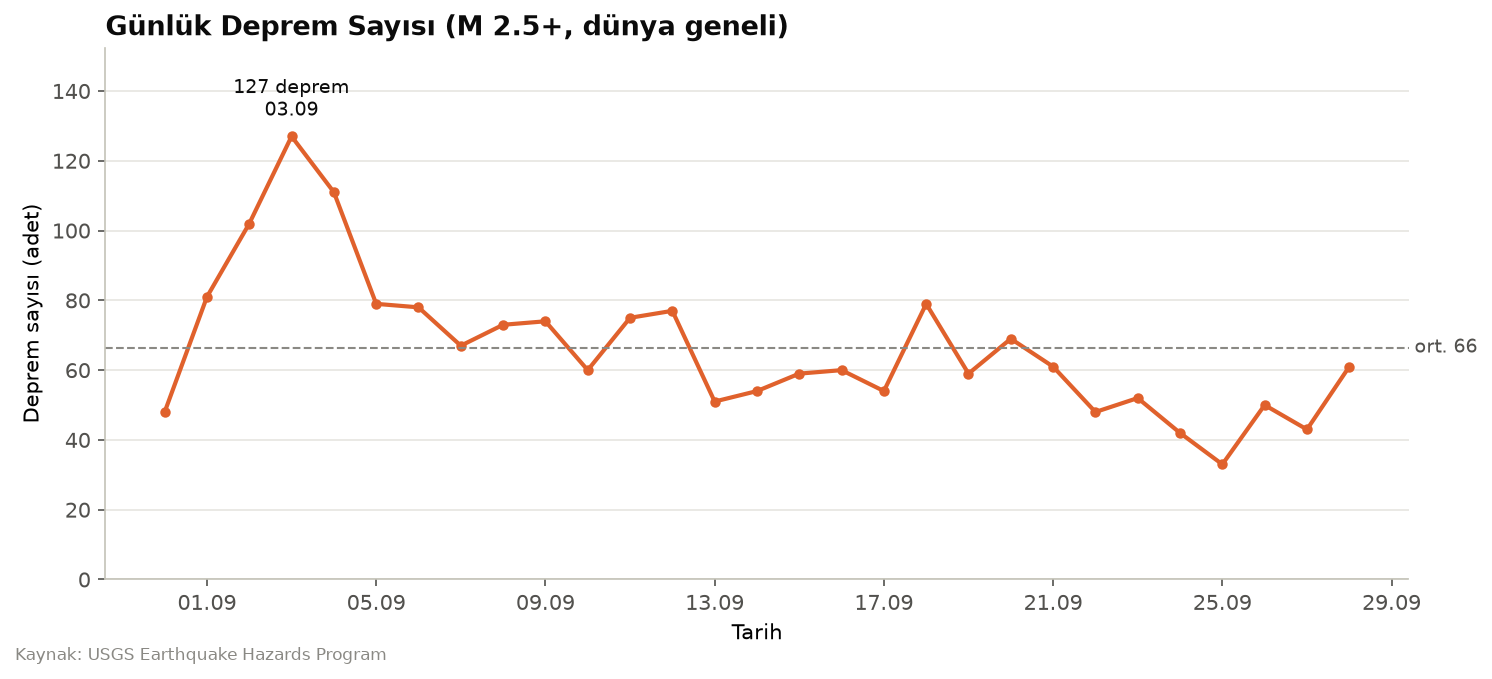

In [8]:
gunluk = df.set_index("zaman").resample("D").size()
gunluk = gunluk.iloc[1:-1]  # yarım günleri at
# Saat dilimi bilgisini atıyoruz: matplotlib aksi halde tarihleri UTC'ye çevirip
# noktaları bir önceki güne kaydırıyor (TSİ 00:00 = UTC 21:00).
gunluk.index = gunluk.index.tz_localize(None)
ort = gunluk.mean()
en_yogun = gunluk.idxmax()

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.plot(gunluk.index, gunluk.values, color="#e0612c", linewidth=2,
        marker="o", markersize=4)
ax.axhline(ort, color="#8a8984", linewidth=1, linestyle="--")
ax.annotate(f" ort. {ort:.0f}", xy=(1, ort), xycoords=("axes fraction", "data"),
            va="center", ha="left", fontsize=9, color="#52514e")
ax.annotate(f"{gunluk.max()} deprem\n{en_yogun:%d.%m}",
            xy=(en_yogun, gunluk.max()), xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9, color="#0b0b0b")

ax.set_title("Günlük Deprem Sayısı (M 2.5+, dünya geneli)", loc="left",
             fontsize=13, fontweight="bold", color="#0b0b0b")
ax.set_xlabel("Tarih")
ax.set_ylabel("Deprem sayısı (adet)")
ax.set_ylim(0, gunluk.max() * 1.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
for kenar in ["top", "right"]:
    ax.spines[kenar].set_visible(False)
for kenar in ["left", "bottom"]:
    ax.spines[kenar].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
fig.text(0.01, 0.01, "Kaynak: USGS Earthquake Hazards Program", fontsize=8, color="#8a8984")
fig.tight_layout()
fig.savefig(CIKTI / "gunluk_deprem_sayisi.png", bbox_inches="tight")
plt.show()

## 7. Bulgular

Türkiye ve çevresi için kaba bir kutu kullanıyoruz (enlem 35.5–42.5, boylam 25.5–45).

In [9]:
en_buyuk = df.loc[df["buyukluk"].idxmax()]
tr = df[df["enlem"].between(35.5, 42.5) & df["boylam"].between(25.5, 45)]

print(f"• Son 30 günde M2.5+ {len(df)} deprem oldu, günde ortalama {ort:.0f}.")
print(f"• En büyüğü M{en_buyuk.buyukluk:.1f}: {en_buyuk.yer} ({en_buyuk.zaman:%d.%m.%Y}).")
print(f"• M5 ve üzeri: {(df['buyukluk'] >= 5).sum()} deprem "
      f"(%{(df['buyukluk'] >= 5).mean()*100:.1f}).")
print(f"• En yoğun gün {en_yogun:%d.%m.%Y}: {gunluk.max()} deprem.")
print(f"• Türkiye ve çevresi: {len(tr)} deprem"
      + (f", en büyüğü M{tr['buyukluk'].max():.1f}." if len(tr) else "."))

• Son 30 günde M2.5+ 1970 deprem oldu, günde ortalama 66.
• En büyüğü M6.6: 80 km ENE of Tadine, New Caledonia (26.09.2026).
• M5 ve üzeri: 156 deprem (%7.9).
• En yoğun gün 03.09.2026: 127 deprem.
• Türkiye ve çevresi: 3 deprem, en büyüğü M5.3.
